In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Load the file data.csv, explore the data showing size and do some data exploration

In [99]:
data = pd.read_csv(filepath_or_buffer="./data.csv", index_col=0)

print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns")

display(data.describe(include="all"))

display(data.info())

display(data.head())

The dataset has 1000 rows and 16 columns


,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
count,50.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,269,NaN,NaN
mean,0.190899,0.464389,0.024135,-0.090224,0.597048,-0.019323,-0.090224,-0.018502,0.017389,-0.090224,0.200876,0.019299,2.481000,NaN,0.163715,0.505000
std,1.664705,1.253621,0.981668,1.047949,1.525925,1.007243,1.047949,1.493104,0.995193,1.047949,1.649333,1.015434,2.280974,NaN,0.534304,0.596935
min,-4.768419,-3.839055,-3.678544,-2.900095,-5.303289,-3.411312,-2.900095,-4.593151,-2.870350,-2.900095,-4.562059,-3.375156,0.000000,NaN,-1.613691,0.000000
25%,-0.653835,-0.261353,-0.643978,-0.847538,-0.302429,-0.635943,-0.847538,-1.070465,-0.650032,-0.847538,-1.024788,-0.657205,1.000000,NaN,-0.213942,0.000000
50%,0.528885,0.554465,0.041989,-0.186079,0.754161,-0.019371,-0.186079,-0.046749,0.041118,-0.186079,0.166277,0.038561,2.000000,NaN,0.148387,0.000000
75%,1.433727,1.289121,0.683684,0.565310,1.647466,0.618085,0.565310,1.049437,0.715784,0.565310,1.347618,0.660219,4.000000,NaN,0.523251,1.000000


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F00     50 non-null     float64
 1   F01     1000 non-null   float64
 2   F02     1000 non-null   float64
 3   F03     1000 non-null   float64
 4   F04     1000 non-null   float64
 5   F05     1000 non-null   float64
 6   F06     1000 non-null   float64
 7   F07     1000 non-null   float64
 8   F08     1000 non-null   float64
 9   F09     1000 non-null   float64
 10  F10     1000 non-null   float64
 11  F11     1000 non-null   float64
 12  F12     1000 non-null   int64  
 13  F13     1000 non-null   object 
 14  F14     1000 non-null   float64
 15  class   1000 non-null   int64  
dtypes: float64(13), int64(2), object(1)
memory usage: 132.8+ KB


None

,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,NaN,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,D,0.078747,1
1,NaN,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,C,-0.277881,1
2,NaN,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,B,1.070634,0
3,NaN,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,B,0.524313,1
4,NaN,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,D,0.411954,2


# 2)  Deal with null values, imputing the mean for numeric features and the string “unknown” for categorical features

In [100]:
# As we could observe from the data.info(), 
# there are not null values in the categorical 
# columns asdf.loc[ "F12", "F13", "class"

# There are null values only in "F00"
data["F00"] = data["F00"].fillna(data["F00"].mean())
data.info()

# I also have to encode the object column "F14" and 
# i could assume an order in the values so i use the ordinal encoder
from sklearn.preprocessing import OrdinalEncoder
df = data.copy()
col_data = np.array(df["F13"]).reshape(-1,1)
df["F13"] = OrdinalEncoder(dtype=int).fit_transform(col_data)
df

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F00     1000 non-null   float64
 1   F01     1000 non-null   float64
 2   F02     1000 non-null   float64
 3   F03     1000 non-null   float64
 4   F04     1000 non-null   float64
 5   F05     1000 non-null   float64
 6   F06     1000 non-null   float64
 7   F07     1000 non-null   float64
 8   F08     1000 non-null   float64
 9   F09     1000 non-null   float64
 10  F10     1000 non-null   float64
 11  F11     1000 non-null   float64
 12  F12     1000 non-null   int64  
 13  F13     1000 non-null   object 
 14  F14     1000 non-null   float64
 15  class   1000 non-null   int64  
dtypes: float64(13), int64(2), object(1)
memory usage: 132.8+ KB


,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,0.190899,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,3,0.078747,1
1,0.190899,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,2,-0.277881,1
2,0.190899,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,1,1.070634,0
3,0.190899,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,1,0.524313,1
4,0.190899,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,3,0.411954,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.190899,-1.402373,0.885475,2.148273,0.648006,-0.404557,2.148273,2.833018,-0.223694,2.148273,0.926656,-0.244994,2,0,0.455047,0
996,0.190899,1.957617,0.230803,-0.224717,2.279944,2.556690,-0.224717,0.500937,-1.264387,-0.224717,-0.061427,0.118506,3,0,0.320055,0
997,-1.401575,-0.423270,0.288753,-0.141635,-0.934012,0.690697,-0.141635,-0.075837,-0.432028,-0.141635,-1.239221,0.648839,1,3,0.430246,1
998,0.190899,0.748535,-0.567256,1.739438,3.901146,0.805824,1.739438,2.965928,0.417743,1.739438,0.664823,0.014587,0,3,0.050071,1


# 3)  train, optimize and test two classifier models of your choice, the optimization must be done with cross validation, optimize the f1-score_macro

In [101]:
# Divide in X and y
X = df.drop(columns="class", axis=1)
y = df["class"]

# Divide in train and test
from sklearn.model_selection import train_test_split, GridSearchCV
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=random_state)
# print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Define the models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Perceptron
from sklearn.metrics import f1_score
models = {
    "dt" : {
        "name" : "Decision Tree",
        "estimator" : DecisionTreeClassifier(random_state=random_state),
        "params" : {
            "criterion" : ["gini", "entropy", "log_loss"],
            "max_depth" : [*range(1,21)]
        }
    },
    "lp" : {
        "name" : "Linear Perceptron",
        "estimator" : Perceptron(random_state=random_state, n_jobs=-1),
        "params" : {
            "early_stopping" : [True, False],
            "class_weight" : [None, "balanced"]
        }
    }
}

# Cross validation optimization for both models
best_params = {}
best_scores = {}
for k, model in models.items():
    gscv = GridSearchCV(
        estimator=model["estimator"],
        param_grid=model["params"],
        scoring="f1_macro",
        n_jobs=-1
    )
    gscv.fit(X_train, y_train)
    best_params[k] = gscv.best_params_
    best_scores[k] = gscv.best_score_
    print(f"In training, for {model['name']} the best params were {best_params[k]} with a f1-score_macro of {best_scores[k]}")

In training, for Decision Tree the best params were {'criterion': 'entropy', 'max_depth': 7} with a f1-score_macro of 0.6386211235667789
In training, for Linear Perceptron the best params were {'class_weight': 'balanced', 'early_stopping': False} with a f1-score_macro of 0.6904863675833482


# 4)  show the result for both models, including the optimal hyperparameter values

In [102]:
# Test the model
for k, model in models.items():
    classifier = model["estimator"].set_params(**best_params[k]).fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    score = f1_score(y_test, y_pred, average="macro")
    print(f"In testing, for {model['name']} with the best parameters {best_params[k]}, the f1-score macro was {score}")

In testing, for Decision Tree with the best parameters {'criterion': 'entropy', 'max_depth': 7}, the f1-score macro was 0.5753178414380601
In testing, for Linear Perceptron with the best parameters {'class_weight': 'balanced', 'early_stopping': False}, the f1-score macro was 0.7103947731854708


The best model is the Linear Perceptron

# 5) repeat the experiment using the best model found in the previous steps and doing feature selection

In testing, for Decision Tree with the best parameters {'criterion': 'entropy', 'max_depth': 7}, the f1-score macro was 0.5753178414380601
In testing, for Linear Perceptron with the best parameters {'class_weight': 'balanced', 'early_stopping': False}, the f1-score macro was 0.7103947731854708
I dropped the features Index(['F00', 'F02', 'F05', 'F07', 'F08', 'F11', 'F12', 'F13'], dtype='object')


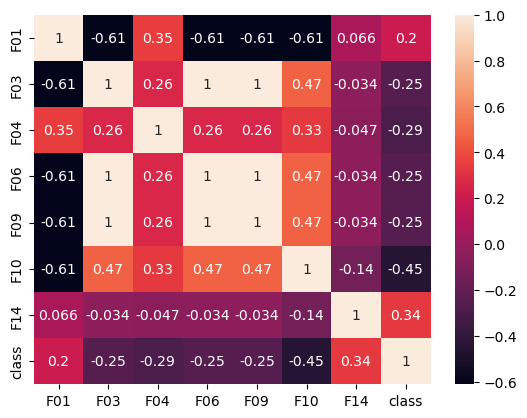

In [103]:
# As a first thing we can exclude values that have too low or too high correlation with the class
class_corr = df.corr().iloc[-1, :-1]

# There are only low correlation attributes
filter_cols = class_corr[class_corr**2 <= 0.01].index
df_selected = df.drop(columns=filter_cols)
# Test the model
for k, model in models.items():
    classifier = model["estimator"].set_params(**best_params[k]).fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    score = f1_score(y_test, y_pred, average="macro")
    print(f"In testing, for {model['name']} with the best parameters {best_params[k]}, the f1-score macro was {score}")
print(f"I dropped the features {filter_cols}")
sns.heatmap(df_selected.corr(), annot=True);

I dropped the features ['F03', 'F06']


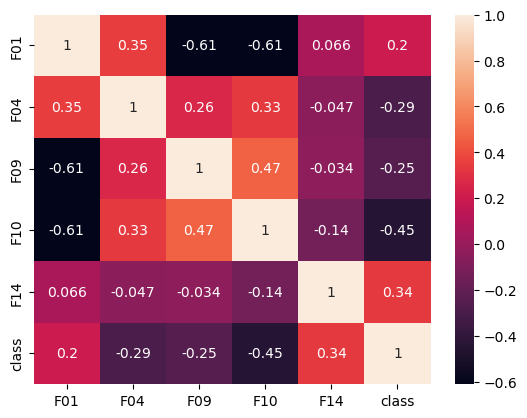

In [104]:
# I also drop "F03" and "F06" as they have the same correlation with the class and ther are too correlated between each other
df_selected_2 = df_selected.drop(columns=["F03", "F06"])
print(f"I dropped the features {['F03', 'F06']}")
sns.heatmap(df_selected_2.corr(), annot=True);

In [105]:
# Repeat the experiment with ethe best classifier

# Divide in X and y
X = df_selected_2.drop(columns="class", axis=1)
y = df_selected_2["class"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=random_state)

model = {
    "name" : "Linear Perceptron",
    "estimator" : Perceptron(random_state=random_state, n_jobs=-1),
    "params" : {
        "early_stopping" : [True, False],
        "class_weight" : [None, "balanced"]
    }
}

# Train
gscv = GridSearchCV(
    estimator=model["estimator"],
    param_grid=model["params"],
    scoring="f1_macro",
    n_jobs=-1
)
gscv.fit(X_train, y_train)
best_params = gscv.best_params_

# Test 
y_pred = gscv.predict(X_test)
score = f1_score(y_test, y_pred, average="macro")

# 6) show the results with the best hyperparameter values

In [106]:
print(f"The score of the Linear Perceptron with the best params ({best_params}) was {score}")

The score of the Linear Perceptron with the best params ({'class_weight': None, 'early_stopping': True}) was 0.4730813287514319


# 7) comment the results of the two experiments

In the experiment we can oberser that the f1_score decreased and this was not expected since with feature selection we dropped columns that seemed to be not correlated with the final class, an explanation could be that correlation is not the only parameter to consider in feature selection and so i could have used for example PCA of selected k-best features for a better overview.